# Autoencoder + UNet Defect Detection

Two-stage workflow: train fold-specific clean-patch autoencoders first, inspect reconstructions, then train one or more UNet segmentation architectures against the saved AE checkpoints and fold splits.

## 1. Setup

In [2]:
import os, sys, socket, importlib
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch


def find_project_root(start=None):
    cur = Path(start or os.getcwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'NNsTorchV2').is_dir():
            return str(candidate)
    raise RuntimeError('Could not find project root containing NNsTorchV2')


PROJECT_ROOT = find_project_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import NNsTorchV2
import NNsTorchV2.HybridTrainV2.GANs.gan_unet_data as gan_unet_data
import NNsTorchV2.HybridTrainV2.GANs.gan_unet_models as gan_unet_models
import NNsTorchV2.HybridTrainV2.GANs.gan_unet_trainer as gan_unet_trainer
import NNsTorchV2.HybridTrainV2.components.infrastructure_V2 as infrastructure_V2
importlib.reload(NNsTorchV2)
importlib.reload(infrastructure_V2)
importlib.reload(gan_unet_data)
importlib.reload(gan_unet_models)
importlib.reload(gan_unet_trainer)

ConvAutoencoder = gan_unet_models.ConvAutoencoder
GANUNetTrainingManager = gan_unet_trainer.GANUNetTrainingManager
load_location = gan_unet_data.load_location
reconstruct_full_image = gan_unet_data.reconstruct_full_image
from NNsTorchV2.HybridTrainV2.components.hybrid_models import SimplerUNet, UNetSE
from NNsTorchV2.core.data_discovery_V2 import discover_data_files_for_location


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


def detect_system():
    h = socket.gethostname()
    if h.startswith('VDI0147'):
        return 'Thermo10'
    if h.startswith('NB'):
        return 'Windows'
    return 'GPU'


SYSTEM = detect_system()
print(f'System: {SYSTEM}')

Device: cpu
System: GPU


## 2. Configuration

In [3]:
# Load .env from project root
_env_path = os.path.join(PROJECT_ROOT, '.env')
if os.path.exists(_env_path):
    with open(_env_path) as _f:
        for _line in _f:
            _line = _line.strip()
            if _line and not _line.startswith('#') and '=' in _line:
                _k, _v = _line.split('=', 1)
                os.environ.setdefault(_k.strip(), _v.strip())

# Data
POWER_MODE = '4kw_both'
SUBFOLDER = 'Taris/Data_ML_V1_h5'
MASK_TYPE = 'alternative'
DATA_REGIME = 'postprocessed'
PPT_PHASES = 'all'
PPT_AMPS = 6
DIRS = [1, 5, 6]
INVERT_MASK = False
MIN_MASK_AREA = 0
MAX_LOC = None

# Autoencoder: train only on nearly clean patches (<1% positive pixels)
AE_PATCH_SIZE = (64, 64)
AE_MAX_POSITIVE_RATIO = 0.005
AE_EPOCHS = 20
AE_BATCH_SIZE = 16
AE_LR = 1e-3
AE_PATIENCE = 8
AE_BASE_CHANNELS = 8
AE_LATENT_CHANNELS = 32
AE_ROT_ANGLE = 0.0
AE_NOISE_STD = 0.05
AE_LOSS_NAME = 'l1_mse'       # 'l1_mse' | 'l1' | 'mse' | 'smooth_l1'
AE_SCHEDULER_NAME = 'cosine'  # AE warmup is optional, cosine is the default

# UNet on abs(original - reconstruction), full locations
UNET_MODEL = 'unet'           # 'unet' | 'unet_se'
UNET_EPOCHS = 20
UNET_BATCH_SIZE = 1
UNET_LR = 1e-3
UNET_PATIENCE = 10
DROPOUT_RATE = 0.0
LOSS_NAME = 'soft_iou'
ALPHA = 0.8
BETA = 0.3
UNET_SCHEDULER_NAME = 'cosine_warmup'
WARMUP_EPOCHS = 3

# Fold/training controls
MODEL_NAME = 'gan_unet'
N_SPLITS = 3
RANDOM_STATE = 42
NUM_WORKERS = 0
OPTIMIZER_NAME = 'adam'
WEIGHT_DECAY = 1e-4
MLFLOW_URI = os.environ.get('MLFLOW_TRACKING_URI', 'sqlite:////tmp/mlflow_experiments/mlflow.db')

# Reuse a previous AE run by setting this to its checkpoint directory.
# Example: AE_RUN_DIR = 'NNsTorchV2/HybridTrainV2/GANs/checkpoints/gan_unet/20260521-135843'
AE_RUN_DIR = None
SPLIT_DIR = None

# Reconstruction preview
FOLD_TO_CHECK = 1
RECON_SAMPLE_COUNT = 3
RECON_PHASE_COMPONENT = 3  # user-facing PPT phase component number, so 3 means component index 2

## 3. Initialise Manager

In [4]:
manager = GANUNetTrainingManager(
    model_name=MODEL_NAME,
    sys=SYSTEM,
    power_mode=POWER_MODE,
    subfolder_name=SUBFOLDER,
    ae_patch_size=AE_PATCH_SIZE,
    ae_max_positive_ratio=AE_MAX_POSITIVE_RATIO,
    ae_base_channels=AE_BASE_CHANNELS,
    ae_latent_channels=AE_LATENT_CHANNELS,
    ae_noise_std=AE_NOISE_STD,
    unet_dropout_rate=DROPOUT_RATE,
    mask_type=MASK_TYPE,
    dirs=DIRS,
    ppt_phases=PPT_PHASES,
    ppt_amps=PPT_AMPS,
    invert_mask=INVERT_MASK,
    data_regime=DATA_REGIME,
    min_mask_area=MIN_MASK_AREA,
    max_locations=MAX_LOC,
    mlflow_uri=MLFLOW_URI,
    loss_name=LOSS_NAME,
    alpha=ALPHA,
    beta=BETA,
    optimizer_name=OPTIMIZER_NAME,
    scheduler_name=UNET_SCHEDULER_NAME,
    ae_scheduler_name=AE_SCHEDULER_NAME,
    unet_scheduler_name=UNET_SCHEDULER_NAME,
    ae_loss_name=AE_LOSS_NAME,
    warmup_epochs=WARMUP_EPOCHS,
    lr=UNET_LR,
    ae_lr=AE_LR,
    weight_decay=WEIGHT_DECAY,
)

UNET_REGISTRY = {
    'unet': lambda: SimplerUNet(in_channels=manager.n_raw_ch, dropout_rate=DROPOUT_RATE),
    'unet_se': lambda: UNetSE(in_channels=manager.n_raw_ch, dropout_rate=DROPOUT_RATE),
}


def build_unet_model():
    if UNET_MODEL not in UNET_REGISTRY:
        raise ValueError(f'Unknown UNET_MODEL={UNET_MODEL!r}. Choose one of {sorted(UNET_REGISTRY)}')
    return UNET_REGISTRY[UNET_MODEL]()


n_params_ae = sum(p.numel() for p in ConvAutoencoder(manager.n_raw_ch, AE_BASE_CHANNELS, AE_LATENT_CHANNELS).parameters())
n_params_unet = sum(p.numel() for p in build_unet_model().parameters())
print(f'Input channels: {manager.n_raw_ch}')
print(f'AE params     : {n_params_ae:,}')
print(f'UNet params   : {n_params_unet:,} ({UNET_MODEL})')
print(f'New checkpoints: {manager.ckpt_dir}')
if AE_RUN_DIR:
    print(f'Reusing AE run : {AE_RUN_DIR}')

Output directory: gan_unet
MLflow tracking: sqlite:////tmp/mlflow_experiments/mlflow.db
n_raw_ch=82  CNN input: (82, 64, 64)  (mode=nn_only)
Device: cpu | samples=27 | channels=82
Input channels: 82
AE params     : 33,162
UNet params   : 489,921 (unet)
New checkpoints: /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/GANs/checkpoints/gan_unet/20260527-102434


## 4. Train Autoencoders

In [ ]:
if AE_RUN_DIR is None:
    ae_results = manager.run_autoencoder_kfold(
        n_splits=N_SPLITS,
        ae_epochs=AE_EPOCHS,
        ae_batch_size=AE_BATCH_SIZE,
        ae_patience=AE_PATIENCE,
        num_workers=NUM_WORKERS,
        random_state=RANDOM_STATE,
        augment_ae=True,
        ae_rot_angle=AE_ROT_ANGLE,
    )
    AE_RUN_DIR = manager.ckpt_dir
    SPLIT_DIR = os.path.join(AE_RUN_DIR, 'fold_splits')
else:
    ae_results = []
    SPLIT_DIR = SPLIT_DIR or os.path.join(AE_RUN_DIR, 'fold_splits')
    print(f'Skipping AE training; using AE_RUN_DIR={AE_RUN_DIR}')

print(f'AE checkpoints: {AE_RUN_DIR}')
print(f'Fold splits   : {SPLIT_DIR}')
for result in ae_results:
    print(f"Fold {result['fold']}: best_loss={result['best_loss']:.5f} checkpoint={result['checkpoint']}")


AE Fold 1/3
TRAIN: 18 - Counter({0: 13, 1: 5})
VAL:   9 - Counter({0: 7, 1: 2})
  AE clean patches: train=757 val=393
    AE Ep   1: train_loss=2.06858 val_loss=2.07969 lr=9.94e-04
    AE Ep   2: train_loss=2.00609 val_loss=1.99965 lr=9.76e-04
    AE Ep   3: train_loss=1.89885 val_loss=1.93626 lr=9.46e-04
    AE Ep   4: train_loss=1.80405 val_loss=1.81193 lr=9.05e-04
    AE Ep   5: train_loss=1.72481 val_loss=1.72248 lr=8.54e-04
    AE Ep   6: train_loss=1.66098 val_loss=1.61232 lr=7.94e-04
    AE Ep   7: train_loss=1.60226 val_loss=1.61754 lr=7.27e-04
    AE Ep   8: train_loss=1.54782 val_loss=1.54225 lr=6.55e-04
    AE Ep   9: train_loss=1.47703 val_loss=1.46451 lr=5.79e-04
    AE Ep  10: train_loss=1.46029 val_loss=1.45541 lr=5.01e-04
    AE Ep  11: train_loss=1.39548 val_loss=1.37876 lr=4.22e-04
    AE Ep  12: train_loss=1.39152 val_loss=1.34235 lr=3.46e-04
    AE Ep  13: train_loss=1.35284 val_loss=1.32893 lr=2.74e-04
    AE Ep  14: train_loss=1.33698 val_loss=1.29231 lr=2.07e-04

## 5. Autoencoder Reconstruction Check

/home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/GANs/gan_unet_trainer.py:273: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = 

Reconstruction preview saved: /home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/GANs/checkpoints/gan_unet/20260527-102434/ae_reconstruction_fold3_phase3.png


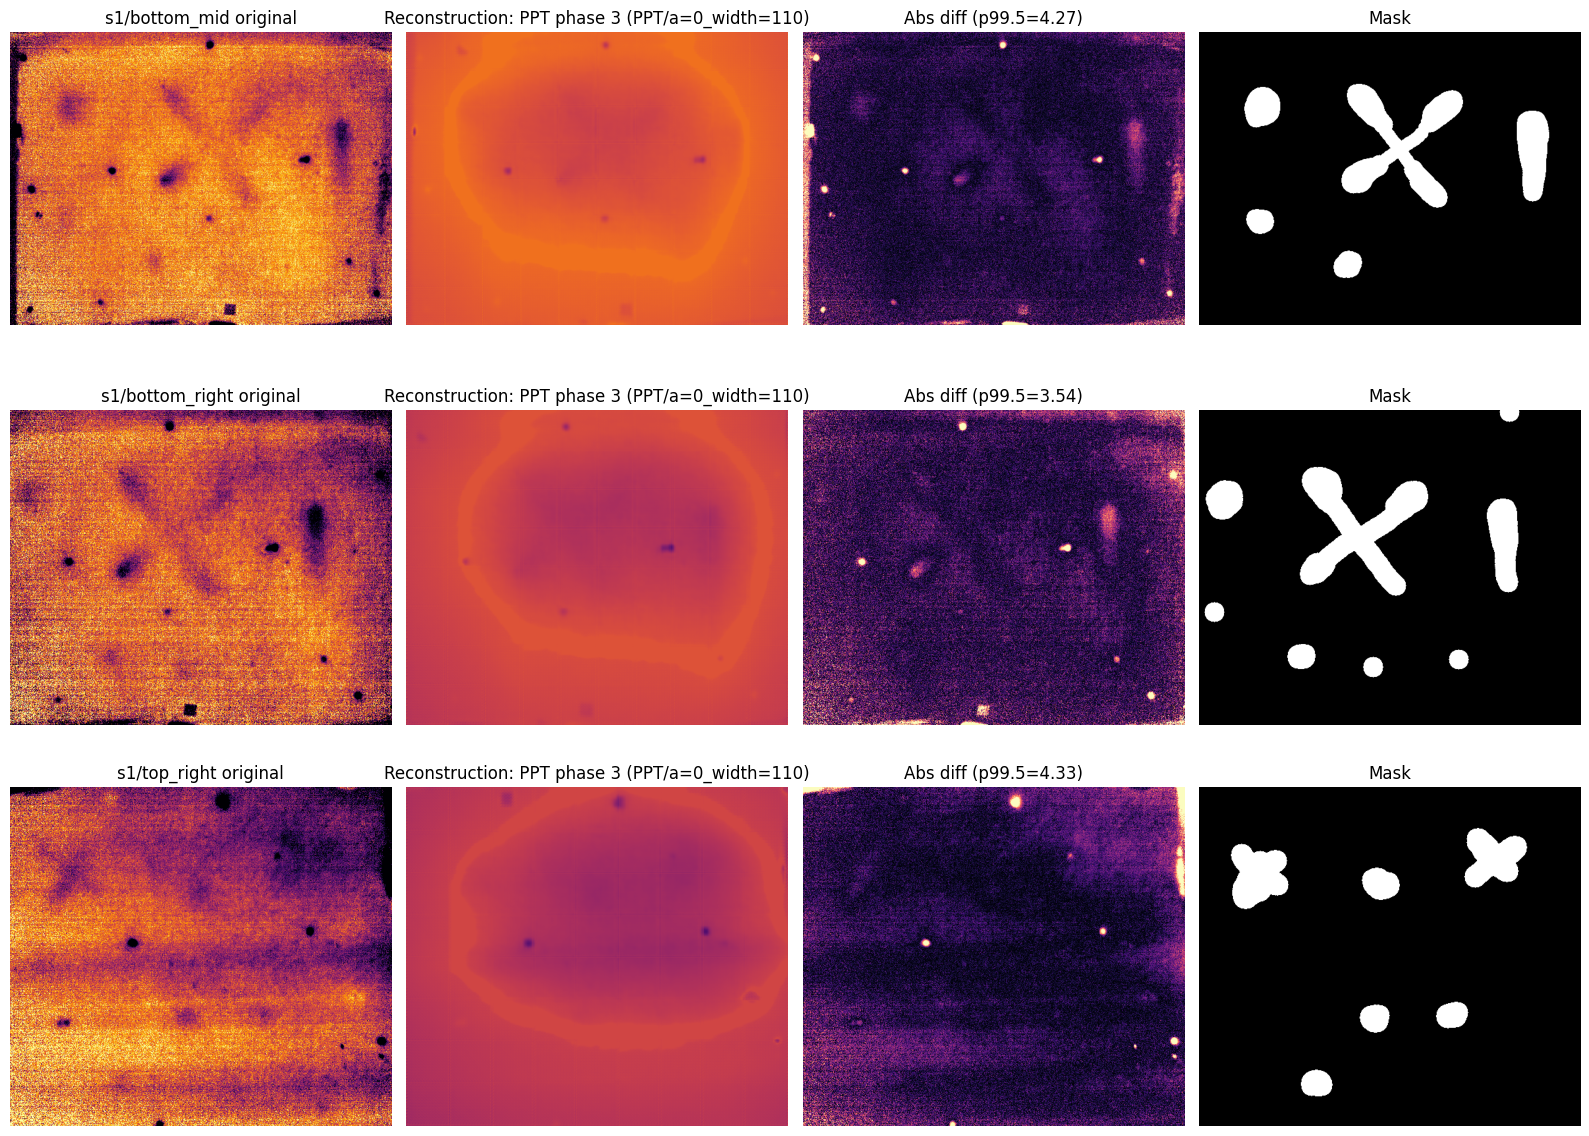

In [7]:
AE_RUN_DIR = '/home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/GANs/checkpoints/gan_unet/20260526-153612'#None  # Set this toreuse a previous AE run by its checkpoint directory.
SPLIT_DIR = os.path.join(AE_RUN_DIR, "fold_splits")
FOLD_TO_CHECK = 3
def _component_count(h5file, group_path):
    return len([k for k in h5file[group_path].keys() if k.startswith('component=')])


def ppt_phase_channel_index(manager, sample, phase_component=3, ppt_variant=0):
    if manager.data_regime == 'raw':
        idx = min(max(0, phase_component - 1), manager.n_raw_ch - 1)
        return idx, f'Raw channel {idx}'

    fi = discover_data_files_for_location(
        manager.load_path,
        manager.power_mode,
        sample[0],
        sample[1],
        mask_type=manager.mask_type,
        data_regime=manager.data_regime,
    )
    offset = 0
    base = fi['base_key']
    with h5py.File(fi['features_h5'], 'r') as f:
        for _, _, rel in fi['PCA']:
            offset += _component_count(f, f'{base}/{rel}')
        for ppt_idx, (_, _, rel) in enumerate(fi['PPT']):
            n_phase_total = _component_count(f, f'{base}/{rel}/Phase')
            n_amp_total = _component_count(f, f'{base}/{rel}/Amp')
            n_phase_used = n_phase_total if manager.ppt_phases == 'all' else min(int(manager.ppt_phases), n_phase_total)
            n_amp_used = min(manager.ppt_amps, n_amp_total)
            if ppt_idx == ppt_variant:
                component_idx = phase_component - 1
                if component_idx < 0 or component_idx >= n_phase_used:
                    raise ValueError(f'PPT phase component {phase_component} not available; using {n_phase_used} phase channels')
                return offset + component_idx, f'PPT phase {phase_component} ({rel})'
            offset += n_phase_used + n_amp_used
    raise ValueError('No PPT phase channels found for this sample')


def robust_limits(*arrays, low=1.0, high=99.0):
    values = [a.ravel() for a in arrays if a.size]
    if not values:
        return 0.0, 1.0
    merged = abs(np.concatenate(values)) if low == 0.0 else np.concatenate(values)
    vmin, vmax = np.percentile(merged, [low, high])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        return float(np.nanmin(merged)), float(np.nanmax(merged) + 1e-6)
    return float(vmin), float(vmax)


assert AE_RUN_DIR is not None, 'Run the AE cell first or set AE_RUN_DIR to an existing checkpoint directory.'
SPLIT_DIR = SPLIT_DIR or os.path.join(AE_RUN_DIR, 'fold_splits')
train_samples, val_samples = manager.load_fold_split(SPLIT_DIR, FOLD_TO_CHECK)
preview_samples = val_samples[:RECON_SAMPLE_COUNT]

ae = manager.load_autoencoder_checkpoint(AE_RUN_DIR, FOLD_TO_CHECK)
channel, channel_label = ppt_phase_channel_index(manager, preview_samples[0], RECON_PHASE_COMPONENT)

fig, axes = plt.subplots(len(preview_samples), 4, figsize=(16, 4 * len(preview_samples)), squeeze=False)
for row, sample in enumerate(preview_samples):
    data, mask = load_location(sample, manager.data_config)
    recon = reconstruct_full_image(ae, data, AE_PATCH_SIZE, manager.device)
    diff = abs(data - recon)
    orig_ch = data[:, :, channel]
    recon_ch = recon[:, :, channel]
    diff_ch = diff[:, :, channel]
    image_vmin, image_vmax = robust_limits(orig_ch, recon_ch, low=1.0, high=99.0)
    _, diff_vmax = robust_limits(diff_ch, low=0.0, high=99.5)

    axes[row, 0].imshow(orig_ch, cmap='inferno', vmin=image_vmin, vmax=image_vmax)
    axes[row, 0].set_title(f'{sample[0]}/{sample[1]} original')
    axes[row, 1].imshow(recon_ch, cmap='inferno', vmin=image_vmin, vmax=image_vmax)
    axes[row, 1].set_title(f'Reconstruction: {channel_label}')
    axes[row, 2].imshow(diff_ch, cmap='magma', vmin=0.0, vmax=diff_vmax)
    axes[row, 2].set_title(f'Abs diff (p99.5={diff_vmax:.3g})')
    axes[row, 3].imshow(mask, cmap='gray')
    axes[row, 3].set_title('Mask')
    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
recon_path = os.path.join(manager.ckpt_dir, f'ae_reconstruction_fold{FOLD_TO_CHECK}_phase{RECON_PHASE_COMPONENT}.png')
fig.savefig(recon_path, dpi=160, bbox_inches='tight')
print(f'Reconstruction preview saved: {recon_path}')

try:
    manager.infra.start_run(f'{manager.versioned_name}_ae_reconstruction_check')
    manager.infra.log_params({
        'stage': 'ae_reconstruction_check',
        'ae_checkpoint_dir': AE_RUN_DIR,
        'fold': FOLD_TO_CHECK,
        'phase_component': RECON_PHASE_COMPONENT,
        'channel_index': channel,
        'channel_label': channel_label,
        'sample_count': len(preview_samples),
    })
    manager.infra.log_artifact(recon_path, artifact_path='reconstruction')
finally:
    manager.infra.end_run()

## 6. Train UNet on Saved AE Reconstructions

In [8]:
assert AE_RUN_DIR is not None, 'Run the AE cell first or set AE_RUN_DIR to an existing checkpoint directory.'
SPLIT_DIR = SPLIT_DIR or os.path.join(AE_RUN_DIR, 'fold_splits')

fold_metrics, avg = manager.run_unet_kfold(
    ae_checkpoint_dir=AE_RUN_DIR,
    split_dir=SPLIT_DIR,
    n_splits=N_SPLITS,
    unet_epochs=UNET_EPOCHS,
    unet_batch_size=UNET_BATCH_SIZE,
    unet_patience=UNET_PATIENCE,
    num_workers=NUM_WORKERS,
    model_fn=build_unet_model,
    model_label=UNET_MODEL,
)


UNet Fold 1/3 (unet)
TRAIN: 18
VAL:   9


/home/aaverin/RZ-Dienste/hpc-user/aaverin/Python/KIprojV2_Claude/NNsTorchV2/HybridTrainV2/GANs/gan_unet_trainer.py:273: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = 

    UNet Ep   1: tr_loss=0.8783 va_loss=0.8522 va_prec=0.1707 va_rec=0.6380 va_f1=0.2670 va_iou=0.1568 lr=4.00e-04
    UNet Ep   2: tr_loss=0.6478 va_loss=0.7251 va_prec=0.3142 va_rec=0.7643 va_f1=0.4347 va_iou=0.2930 lr=7.00e-04


/home/aaverin/miniforge3/envs/pytorch_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


    UNet Ep   3: tr_loss=0.5086 va_loss=0.8206 va_prec=0.1876 va_rec=0.7619 va_f1=0.2993 va_iou=0.1809 lr=1.00e-03
    UNet Ep   4: tr_loss=0.4835 va_loss=0.6985 va_prec=0.3299 va_rec=0.7971 va_f1=0.4540 va_iou=0.3061 lr=9.91e-04
    UNet Ep   5: tr_loss=0.4611 va_loss=0.6362 va_prec=0.4093 va_rec=0.7179 va_f1=0.5080 va_iou=0.3686 lr=9.66e-04
    UNet Ep   6: tr_loss=0.4531 va_loss=0.5384 va_prec=0.6561 va_rec=0.5744 va_f1=0.5987 va_iou=0.4701 lr=9.25e-04
    UNet Ep   7: tr_loss=0.4113 va_loss=0.5793 va_prec=0.5001 va_rec=0.7423 va_f1=0.5717 va_iou=0.4287 lr=8.70e-04
    UNet Ep   8: tr_loss=0.4226 va_loss=0.5178 va_prec=0.6073 va_rec=0.6978 va_f1=0.6262 va_iou=0.4900 lr=8.02e-04
    UNet Ep   9: tr_loss=0.3966 va_loss=0.4937 va_prec=0.6730 va_rec=0.6533 va_f1=0.6454 va_iou=0.5152 lr=7.23e-04
    UNet Ep  10: tr_loss=0.4057 va_loss=0.5420 va_prec=0.7171 va_rec=0.5452 va_f1=0.6045 va_iou=0.4663 lr=6.37e-04
    UNet Ep  11: tr_loss=0.3953 va_loss=0.5463 va_prec=0.5378 va_rec=0.7449 va_f

## 7. Results

In [ ]:
names = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1', 'IoU']
print(f'UNet model: {UNET_MODEL}')
print(f'AE run    : {AE_RUN_DIR}')
print(f'UNet ckpts: {manager.ckpt_dir}')
print('-' * 72)
for i, fm in enumerate(fold_metrics):
    print(f'Fold {i + 1}: ' + '  '.join(f'{n}={v:.4f}' for n, v in zip(names, fm)))
print('=' * 72)
print('Average:')
for n, v in zip(names, avg):
    print(f'  {n:12s}: {v:.4f}')